# EE2211 Tutorial 8

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import pandas as pd

[[ 100.63210529]
 [-100.7837008 ]]


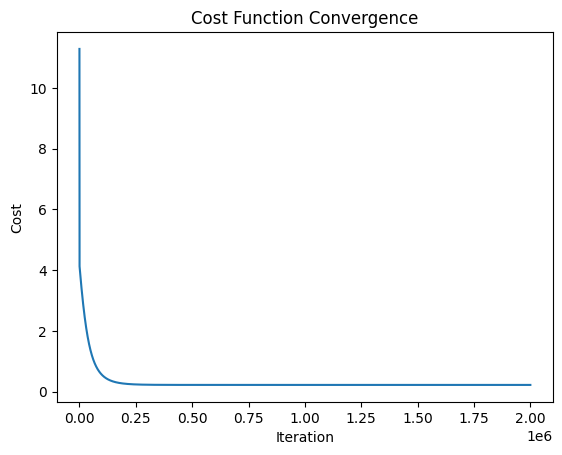

In [21]:
#Question 1:

df = pd.read_csv("government-expenditure-on-education.csv")

X = df["year"].values
y = df["total_expenditure_on_education"].values

X_norm = X/np.max(X)
y_norm = (y/np.max(y)).reshape(-1,1)

X_w = np.column_stack([np.ones(X.shape[0]), X_norm])

lr = 0.03

w = np.array([0,0]).reshape(-1,1)

num_iters = 2*10**6
C = np.zeros(num_iters)

for i in range(2*10**6):
    grad = -2*X_w.T@(np.exp(-X_w @ w) * (np.exp(-X_w @ w) - y_norm))
    w = w - lr*grad
    C[i] = np.sum((np.exp(-X_w @ w) - y_norm)**2)

print(w)

plt.plot(C)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function Convergence')
plt.show()


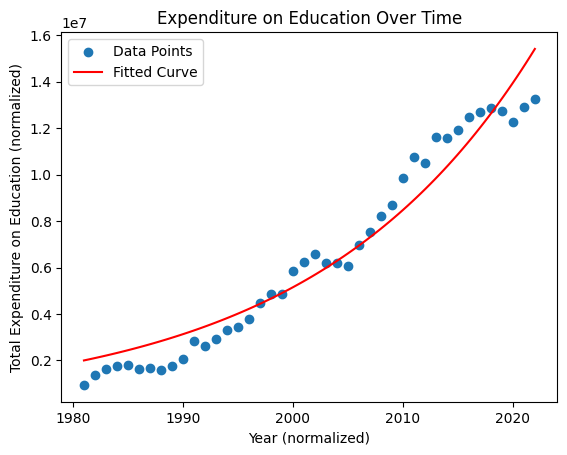

In [22]:
x_labels = np.linspace(X_norm.min(), X_norm.max(), 100)
p = np.exp(-w[0] - w[1]*x_labels)
#plot the actual data points and the fitted curve undoing normalisation
p = p * np.max(y)
x_labels = x_labels * np.max(X)
plt.scatter(X, y, label='Data Points')
plt.plot(x_labels, p, color='red', label='Fitted Curve')
plt.xlabel('Year (normalized)')
plt.ylabel('Total Expenditure on Education (normalized)')
plt.legend()
plt.title('Expenditure on Education Over Time')
plt.show()

c:\Users\krith\NUS-Modules\EE2211\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


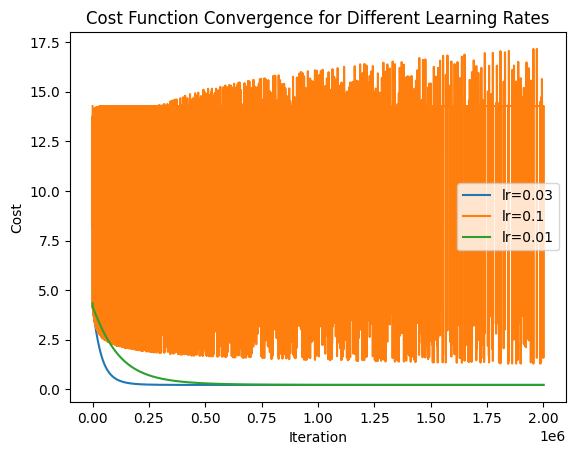

In [24]:
#repeat with lr = 0.1 and lr = 0.01 and compare the convergence of the cost function.

w_1 = np.array([0,0]).reshape(-1,1)
C_1 = np.zeros(num_iters)
w_2 = np.array([0,0]).reshape(-1,1)
C_2 = np.zeros(num_iters)
for i in range(num_iters):
    grad = -2*X_w.T@(np.exp(-X_w @ w_1) * (np.exp(-X_w @ w_1) - y_norm))
    w_1 = w_1 - 0.1*grad
    C_1[i] = np.sum((np.exp(-X_w @ w_1) - y_norm)**2)

for i in range(num_iters):
    grad = -2*X_w.T@(np.exp(-X_w @ w_2) * (np.exp(-X_w @ w_2) - y_norm))
    w_2 = w_2 - 0.01*grad
    C_2[i] = np.sum((np.exp(-X_w @ w_2) - y_norm)**2)

plt.plot(C, label='lr=0.03')
plt.plot(C_1, label='lr=0.1')
plt.plot(C_2, label='lr=0.01')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function Convergence for Different Learning Rates')
plt.legend()
plt.show()

Part A: Final weights = [ 100.63210536 -100.58432658]


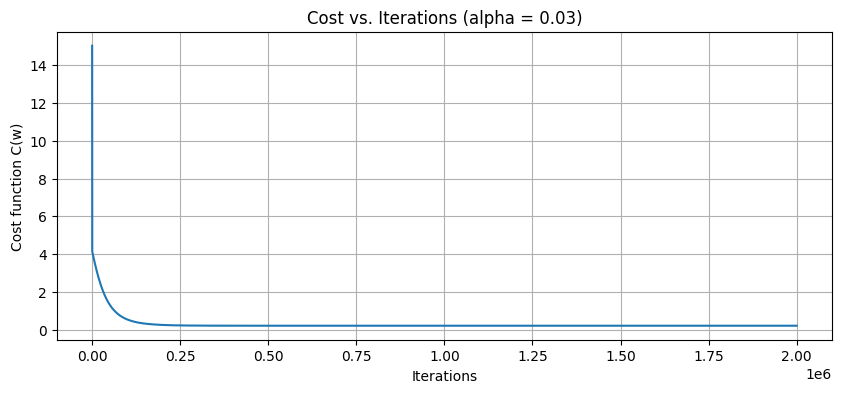

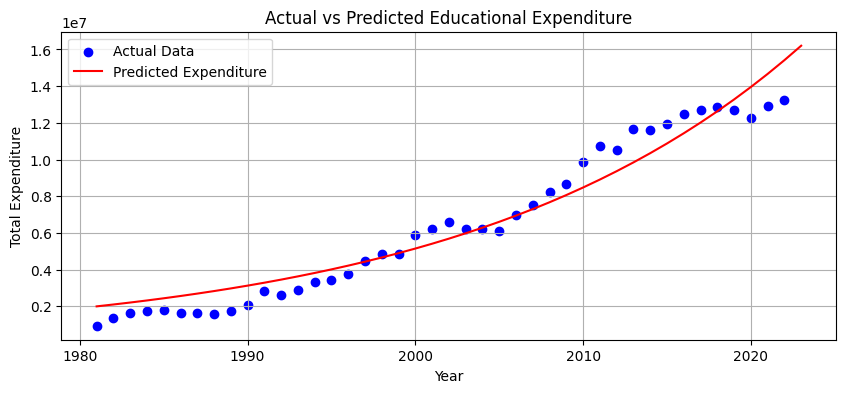

c:\Users\krith\NUS-Modules\EE2211\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


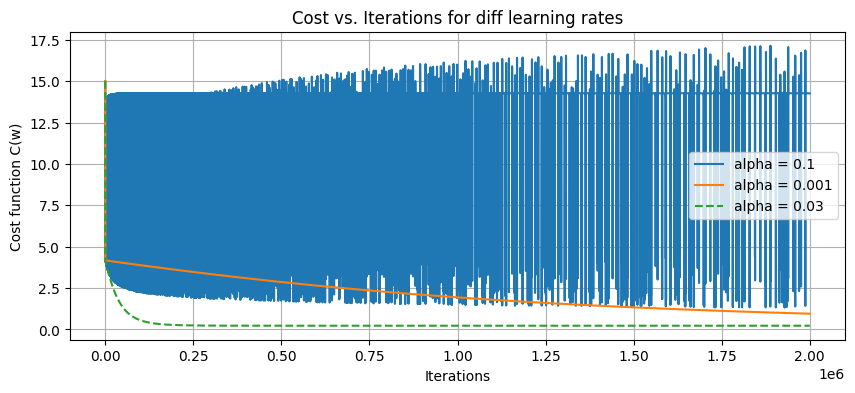

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- PREPROCESSING ---
# The CSV is available 3 folders up (adjust as needed if it moves).
csv_path = '../../Tutorial_solutions/Tutorial 2 supp government-expenditure-on-education.csv'
df = pd.read_csv(csv_path)

x = df['year'].values
y = df['total_expenditure_on_education'].values

# Normalize variables
max_year = 2018
max_y = y.max()

x_norm = x / max_year
y_norm = y / max_y

# Construct the feature matrix X with a bias term (N x 2)
# The row i is [1, x_norm[i]]
X = np.c_[np.ones(len(x_norm)), x_norm]

# --- GRADIENT DESCENT FUNCTION ---
def run_gradient_descent(X, y, alpha, num_iters):
    # Initialize weights
    w = np.array([0.0, 0.0])
    cost_history = []
    
    for _ in range(num_iters):
        # f(x, w) = exp(-x^T w)
        # Using vectorised form for all rows in X at once
        f = np.exp(-X @ w)
        
        # error term = f_i - y_i
        error = f - y
        
        # Calculate Cost function
        cost = np.sum(error ** 2)
        cost_history.append(cost)
        
        # Gradient = sum(-2 * (f - y) * f * x_i)
        # In vectorized operations: -X.T @ (2 * error * f)
        grad = -X.T @ (2 * error * f)
        
        w = w - alpha * grad
        
    return w, cost_history

# --- PART (A): alpha = 0.03 ---
alpha_a = 0.03
iters = 2000000
w_a, costs_a = run_gradient_descent(X, y_norm, alpha_a, iters)

print("Part A: Final weights =", w_a)

plt.figure(figsize=(10, 4))
plt.plot(costs_a)
plt.xlabel('Iterations')
plt.ylabel('Cost function C(w)')
plt.title(f'Cost vs. Iterations (alpha = {alpha_a})')
plt.grid(True)
plt.show()

# --- PART (B): Plot predicted expenditure from 1981 to 2023 ---
years_pred = np.arange(1981, 2024)
years_pred_norm = years_pred / max_year

X_pred = np.c_[np.ones(len(years_pred_norm)), years_pred_norm]
f_pred_norm = np.exp(-X_pred @ w_a)

# Un-normalize the predicted y
f_pred = f_pred_norm * max_y

plt.figure(figsize=(10, 4))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(years_pred, f_pred, color='red', label='Predicted Expenditure')
plt.xlabel('Year')
plt.ylabel('Total Expenditure')
plt.title('Actual vs Predicted Educational Expenditure')
plt.legend()
plt.grid(True)
plt.show()

# --- PART (C): Plot for learning rate 0.1 and 0.001 ---
alphas_c = [0.1, 0.001]
plt.figure(figsize=(10, 4))

for a in alphas_c:
    _, costs = run_gradient_descent(X, y_norm, a, iters)
    plt.plot(costs, label=f'alpha = {a}')

plt.plot(costs_a, label=f'alpha = {alpha_a}', linestyle='--')
plt.xlabel('Iterations')
plt.ylabel('Cost function C(w)')
plt.title('Cost vs. Iterations for diff learning rates')
plt.legend()
plt.grid(True)
plt.show()